In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#import excel 
excel_file = pd.read_excel("CoffeeData.xlsx")


sheets = pd.read_excel("CoffeeData.xlsx", sheet_name =None)
sheets.keys()

fact = sheets['factTable']
location = sheets['location']
product = sheets['product']

sheets.keys()

dict_keys(['factTable', 'location', 'product'])

In [2]:
fact.columns

Index(['Profit', 'Margin', 'Sales', 'COGS', 'Total Expenses', 'Marketing',
       'Inventory', 'Budget Profit', 'Budget COGS', 'Budget Margin',
       'Budget Sales', 'Area Code', 'ProductId', 'Date'],
      dtype='object')

In [3]:
location.columns

Index(['Area Code', 'State', 'Market', 'Market Size'], dtype='object')

In [4]:
product.columns

Index(['Product Type', 'Product', 'ProductId', 'Type'], dtype='object')

In [5]:
df = fact.merge(
    product,
    on = "ProductId",
    how = "left"
)

df = df.merge(
    location, 
    on = "Area Code",
    how = "left"
)
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Profit          4248 non-null   int64 
 1   Margin          4248 non-null   int64 
 2   Sales           4248 non-null   int64 
 3   COGS            4248 non-null   int64 
 4   Total Expenses  4248 non-null   int64 
 5   Marketing       4248 non-null   int64 
 6   Inventory       4248 non-null   int64 
 7   Budget Profit   4248 non-null   int64 
 8   Budget COGS     4248 non-null   int64 
 9   Budget Margin   4248 non-null   int64 
 10  Budget Sales    4248 non-null   int64 
 11  Area Code       4248 non-null   int64 
 12  ProductId       4248 non-null   int64 
 13  Date            4248 non-null   object
 14  Product Type    4248 non-null   object
 15  Product         4248 non-null   object
 16  Type            4248 non-null   object
 17  State           4248 non-null   object
 18  Market  

,Profit,Margin,Sales,COGS,Total Expenses,Marketing,Inventory,Budget Profit,Budget COGS,Budget Margin,Budget Sales,Area Code,ProductId
count,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000,4248.000000
mean,50.229755,108.554379,192.987524,84.433145,54.063559,31.185028,749.381356,60.913371,74.830508,100.819209,175.649718,582.278013,6.887006
std,82.251021,96.646250,151.133127,67.249769,32.352598,27.023264,661.031896,79.546123,66.238145,92.602725,148.891522,221.140310,3.664072
min,-449.000000,-283.000000,17.000000,0.000000,10.000000,0.000000,-3534.000000,-320.000000,0.000000,-210.000000,0.000000,203.000000,1.000000
25%,15.000000,55.000000,100.000000,43.000000,33.000000,13.000000,432.000000,20.000000,30.000000,50.000000,80.000000,417.000000,4.000000
50%,33.000000,80.000000,138.000000,60.000000,46.000000,22.000000,619.000000,40.000000,50.000000,70.000000,130.000000,573.000000,6.000000
75%,78.000000,139.000000,230.000000,100.000000,65.000000,39.000000,910.500000,80.000000,90.000000,130.000000,210.000000,772.000000,10.000000
max,567.000000,613.000000,912.000000,364.000000,190.000000,156.000000,8252.000000,560.000000,450.000000,690.000000,1140.000000,985.000000,13.000000


In [6]:
#total sales
total_sales = df["Sales"].sum()


#Sales by product type
product_sales = (
    df.groupby("Product Type")["Sales"]
    .sum()
    .sort_values(ascending = False)
)

product_sales


Product Type
Espresso      222996
Coffee        216828
Herbal Tea    207214
Tea           172773
Name: Sales, dtype: int64

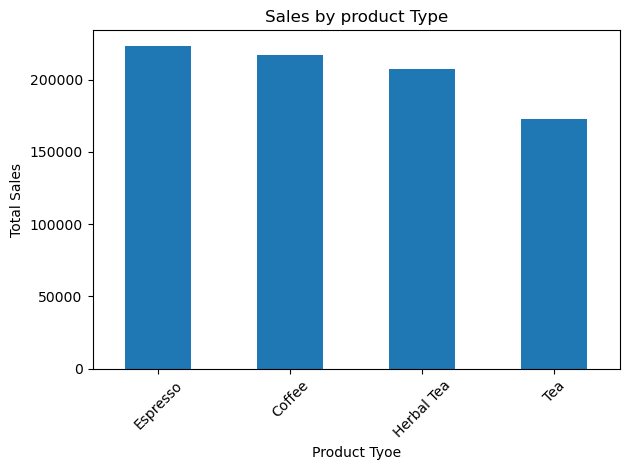

In [24]:
#visual 

product_sales.plot(
    kind = "bar",
    title = "Sales by product Type"
)

plt.xlabel("Product Tyoe")
plt.ylabel("Total Sales")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [8]:
df.columns


Index(['Profit', 'Margin', 'Sales', 'COGS', 'Total Expenses', 'Marketing',
       'Inventory', 'Budget Profit', 'Budget COGS', 'Budget Margin',
       'Budget Sales', 'Area Code', 'ProductId', 'Date', 'Product Type',
       'Product', 'Type', 'State', 'Market', 'Market Size'],
      dtype='object')

In [9]:
# KPI 5: COGS ANALYSIS

product_cogs = ( 
    df.groupby("Product")["COGS"]
    .sum()
    .sort_values(ascending = False)
)

product_cogs

Product
Columbian            48396
Lemon                41494
Caffe Mocha          37990
Decaf Espresso       33318
Chamomile            31386
Darjeeling           30534
Decaf Irish Cream    29568
Earl Grey            28554
Mint                 19930
Green Tea            19078
Caffe Latte          15294
Amaretto             12732
Regular Espresso     10398
Name: COGS, dtype: int64

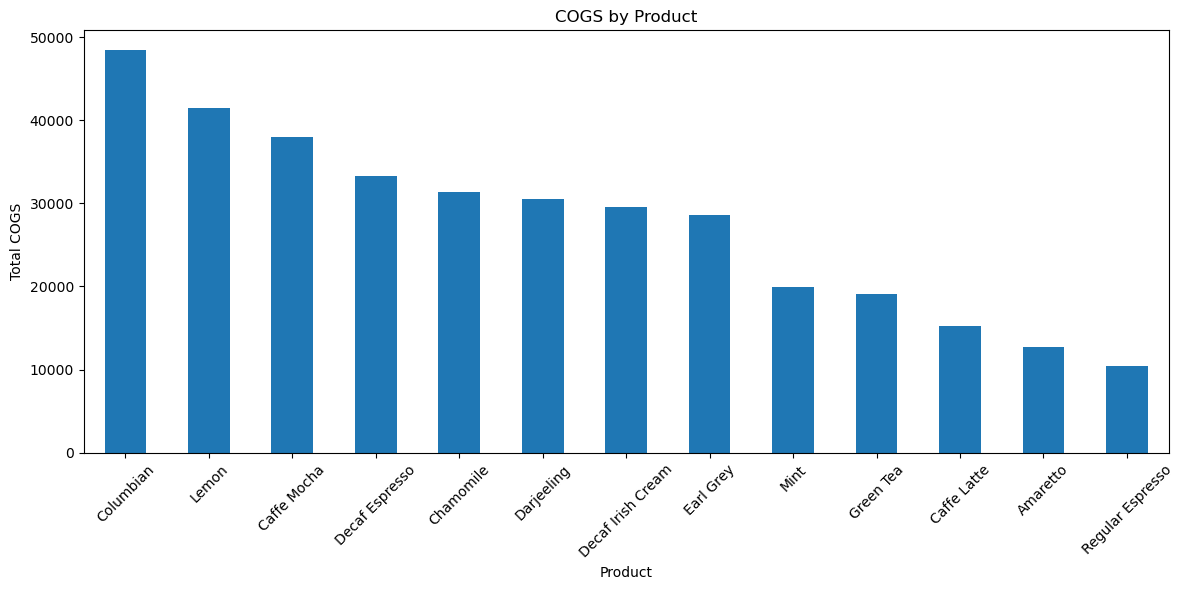

In [22]:
product_cogs.plot(
    kind = "bar",
    figsize = (12,6),
    title = "COGS by Product"
)

plt.xlabel("Product")
plt.ylabel("Total COGS")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


In [12]:
#KPI 6: Profit by Market

market_profit = (
    df.grouby("Market")["Profit"]
        .sum()
        .sort_values(ascending = false)
)
print(market_profit)
    

Market
Central    77219
West       60538
East       48829
South      26790
Name: Profit, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

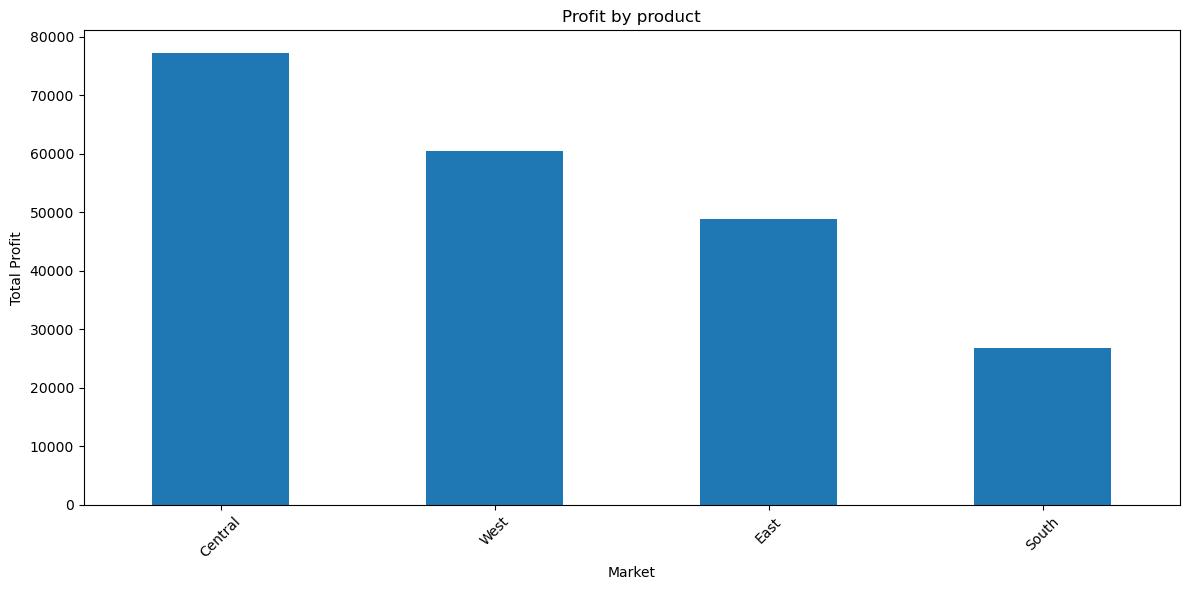

In [19]:
#visual

market_profit.plot(
kind = "bar",
figsize= (12,6),
title="Profit by product"
)

plt.xlabel("Market")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

In [ ]:
#